In [1]:
import random
import numpy as np
import pylab as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, RandomSampler
from tqdm import tqdm

from sklearn import datasets

import sys
sys.path.append('../../')
from notebook_utils import Net, plot_dset, plot_contour, dataset_to_xy

In [2]:
X, y = datasets.make_moons(250, noise=.05, random_state=42)
X = (X - X.mean(0)) / X.std(0)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()

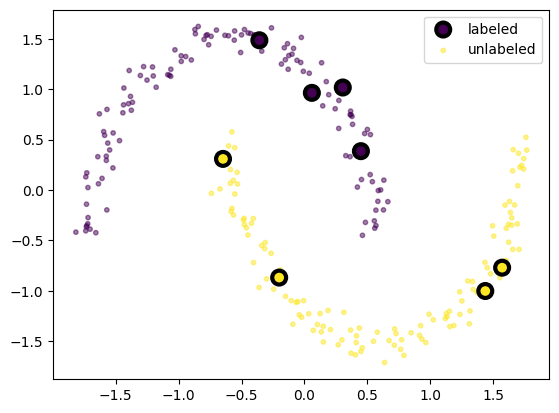

In [3]:
random.seed(1)
indices_class0 = [i for i in range(len(y)) if y[i] == 0]
indices_class1 = [i for i in range(len(y)) if y[i] == 1]
labeled_indices = random.sample(indices_class0, k=4) + random.sample(indices_class1, k=4)
unlabeled_indices = [i for i in range(X.shape[0]) if i not in labeled_indices]

X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]
X_unlabeled, y_unlabeled = X[unlabeled_indices], y[unlabeled_indices]
labeled_ds = torch.utils.data.TensorDataset(X_labeled, y_labeled)

plot_dset(X_l=X_labeled, y_l=y_labeled, X_u=X_unlabeled, y_u=y_unlabeled)

## Fully-Supervised-Model

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: /home/phahn/repositories/dal-toolbox/examples/supervised_learning/toy_examples/lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | Net              | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


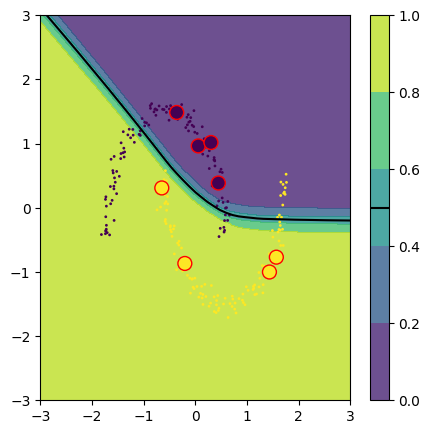

In [4]:
import lightning as L
from dal_toolbox.models.deterministic import DeterministicModel

torch.manual_seed(0)

num_epochs = 100 # number of epochs for training
batch_size = 32 # batch_size of labeled samples per iteration
opt_kwargs = dict(lr=0.01, weight_decay=0.0001, momentum=.9,)

labeled_loader = DataLoader(labeled_ds, batch_size=batch_size, shuffle=True)

model = Net(dropout_rate=0, num_classes=2)
optimier = torch.optim.SGD(model.parameters(), **opt_kwargs)
criterion = torch.nn.CrossEntropyLoss()
model = DeterministicModel(model, criterion, optimier)

trainer = L.Trainer(enable_checkpointing=False, max_epochs=num_epochs)
trainer.fit(model, labeled_loader)
    
model.eval()
plt.figure(figsize=(5, 5))
plot_contour(model, X_labeled, y_labeled, X_unlabeled, y_unlabeled)
plt.show()